In [1]:
# 캐글의 **Mall Customer Segmentation Data**를 사용하여 다음을 수행하시오.
# - Annual Income과 Spending Score 두 개의 feature만 사용하시오.
# - 필요 시 정규화(StandardScaler 또는 MinMaxScaler)를 적용하시오.
# - 군집 수를 결정해,  K-Means를 적용하시오.
# - 결과를 시각화하고 특징을 간단히 설명하시오.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('./Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
# - Annual Income과 Spending Score 두 개의 feature만 사용하시오.
features = df[['Annual Income (k$)', 'Spending Score (1-100)']]
features

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [5]:
# - 필요 시 정규화(StandardScaler 또는 MinMaxScaler)를 적용하시오.
sc=StandardScaler()
features_sc=sc.fit_transform(features)

In [6]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)

In [7]:
features_pca=pca.fit_transform(features_sc)

In [8]:
print(pca.explained_variance_ratio_)

[0.50495142 0.49504858]


In [9]:
# - 군집 수를 결정해,  K-Means를 적용하시오.
from sklearn.cluster import KMeans

k_means=KMeans(n_clusters=3)

k_means.fit(features_pca)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [10]:
k_means.labels_

centers=k_means.cluster_centers_

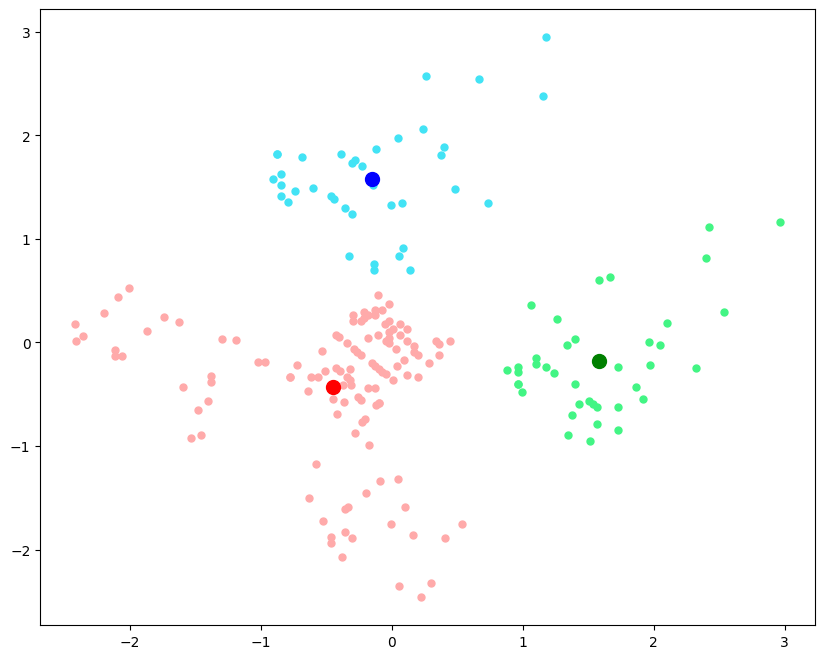

In [11]:
# - 결과를 시각화하고 특징을 간단히 설명하시오.
from matplotlib.colors import ListedColormap

color_bold=ListedColormap(['red','blue','green'])
color_light=ListedColormap(['#FFAAAA','#42e3f5','#42f584'])

plt.figure(figsize=(10,8))

for i in range(3):
    clusters=k_means.labels_ == i
    plt.plot(features_pca[clusters,0], features_pca[clusters, 1], '.', c=color_light(i), markersize=10)
    plt.plot(centers[i,0], centers[i,1], 'o', c=color_bold(i), markersize=10)